In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer

In [3]:
df = pd.read_csv('concrete_data.csv')

In [4]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [7]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [8]:
x = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.6275531792314848

In [21]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [15]:
np.mean(cross_val_score(lr,x_train,y_train,scoring='r2'))

np.float64(0.5946055391992532)

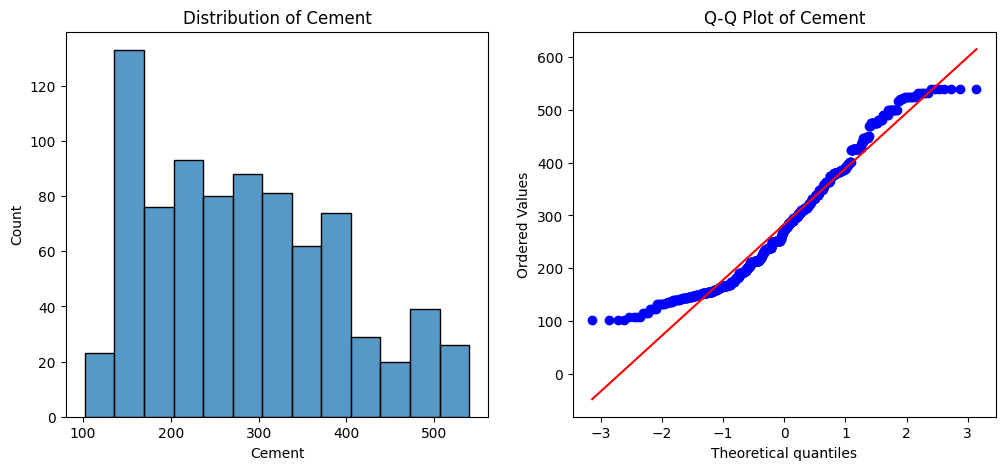

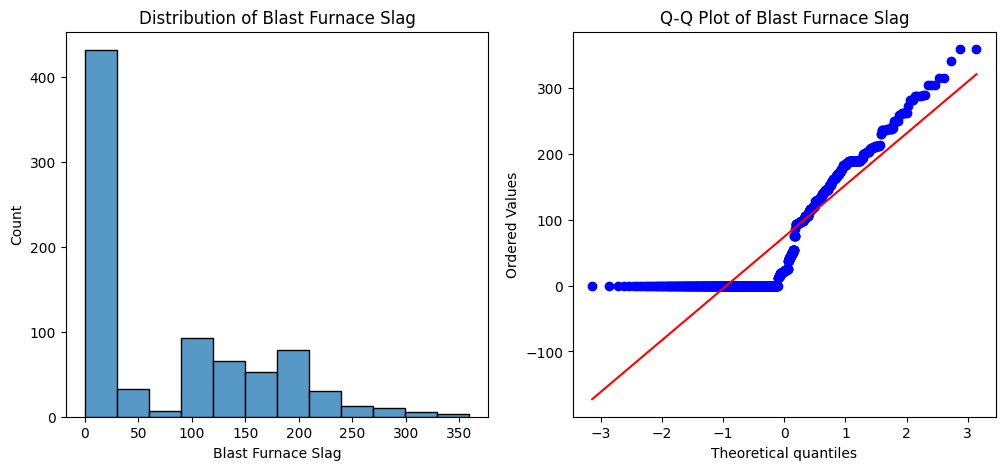

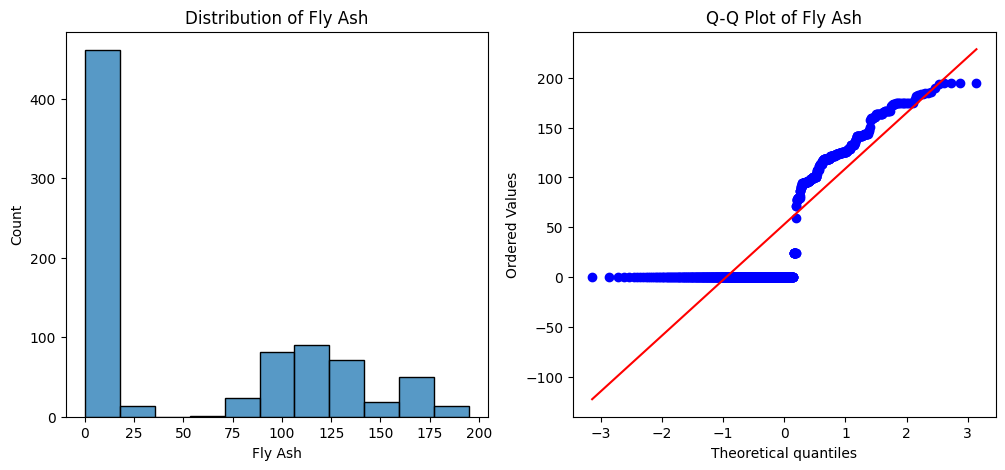

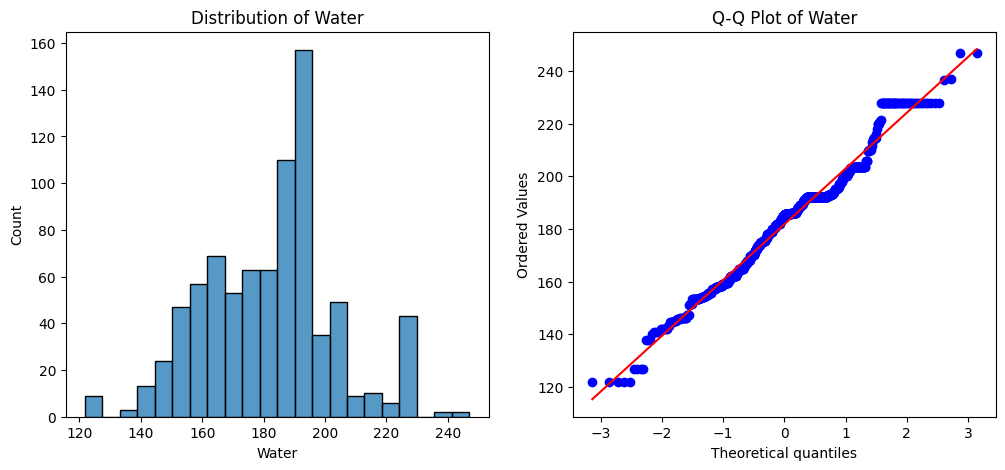

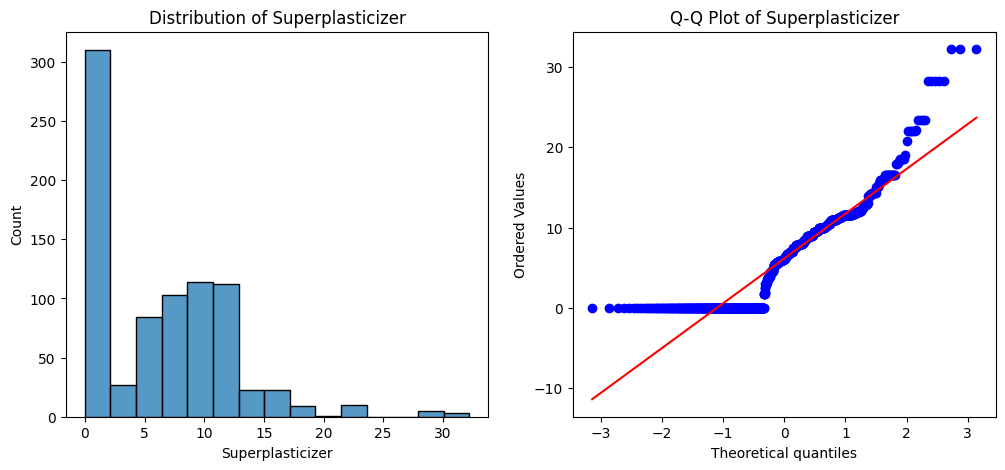

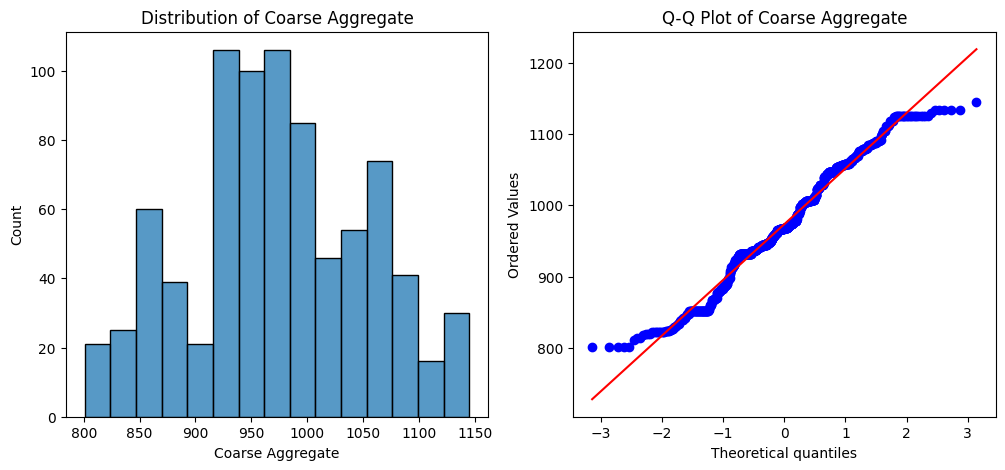

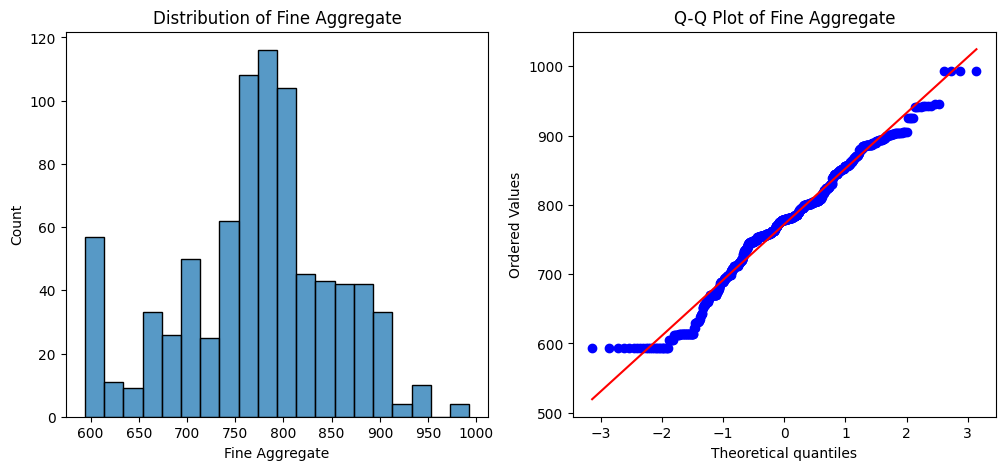

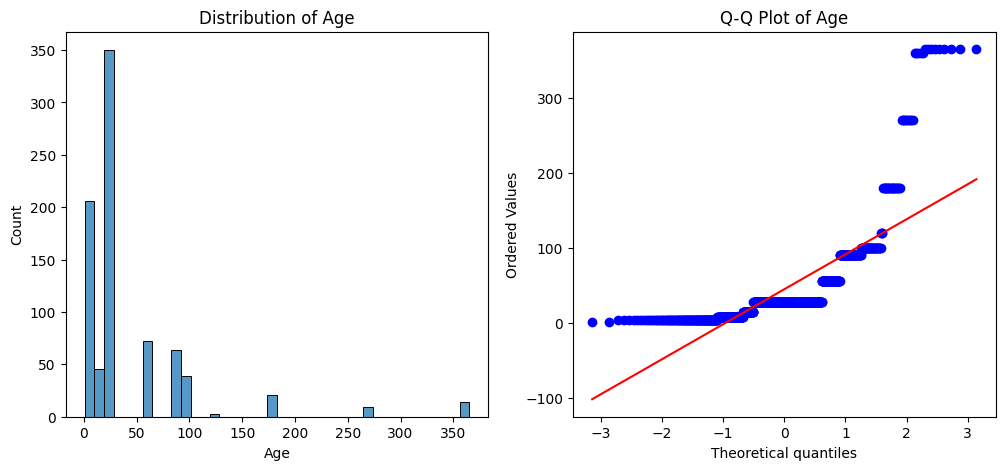

In [20]:
for col in x_train.columns:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Distribution plot
    sns.histplot(x_train[col], ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")
    
    # Q-Q plot
    stats.probplot(x_train[col], dist="norm", plot=ax[1])
    ax[1].set_title(f"Q-Q Plot of {col}")
    
    plt.show()

In [24]:
trf = FunctionTransformer(func=np.log1p)

In [25]:
X_train_transformed = trf.fit_transform(x_train)
X_test_transformed = trf.transform(x_test)

In [26]:
np.mean(cross_val_score(lr,X_train_transformed,y_train,scoring='r2'))

np.float64(0.7929089124587646)

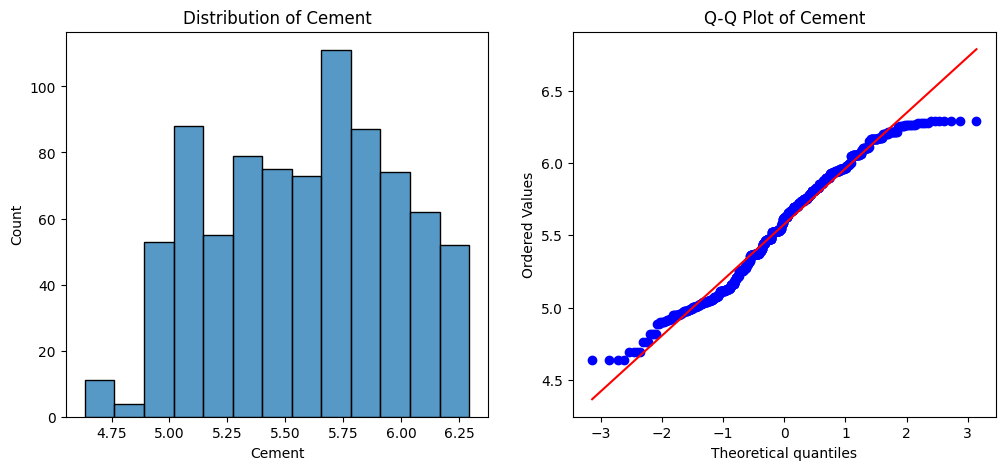

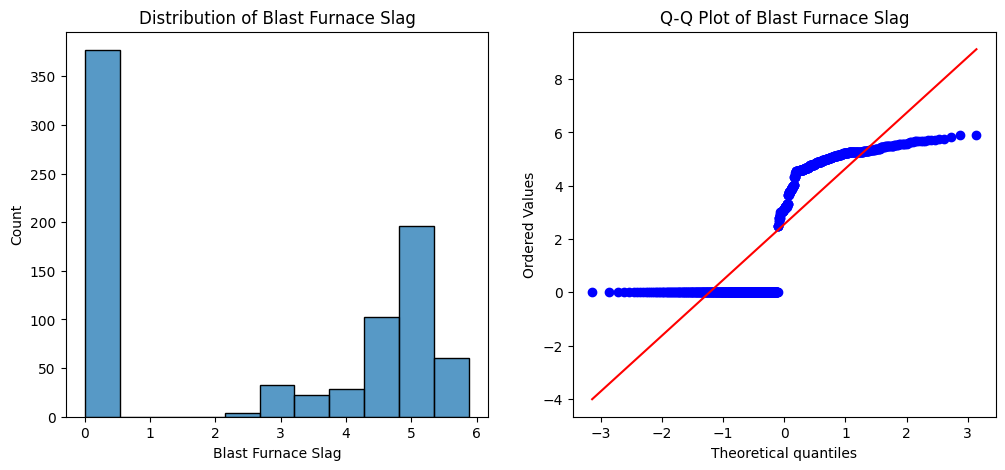

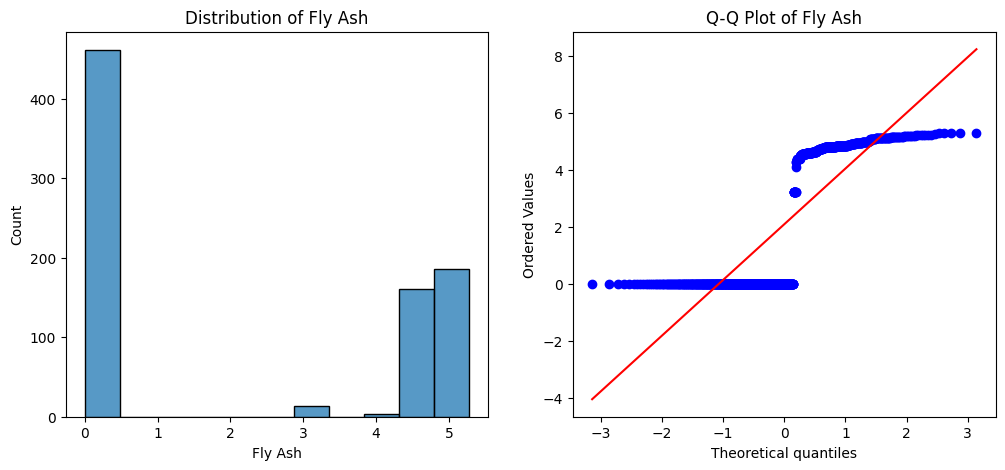

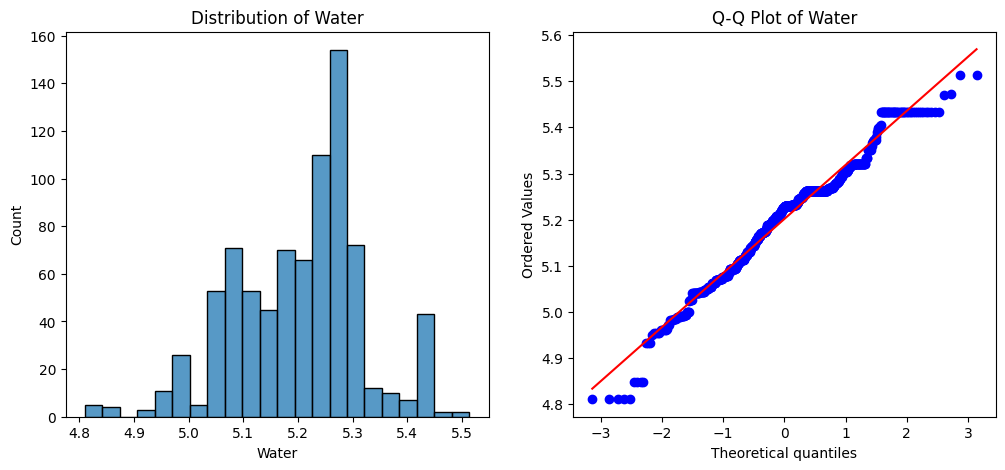

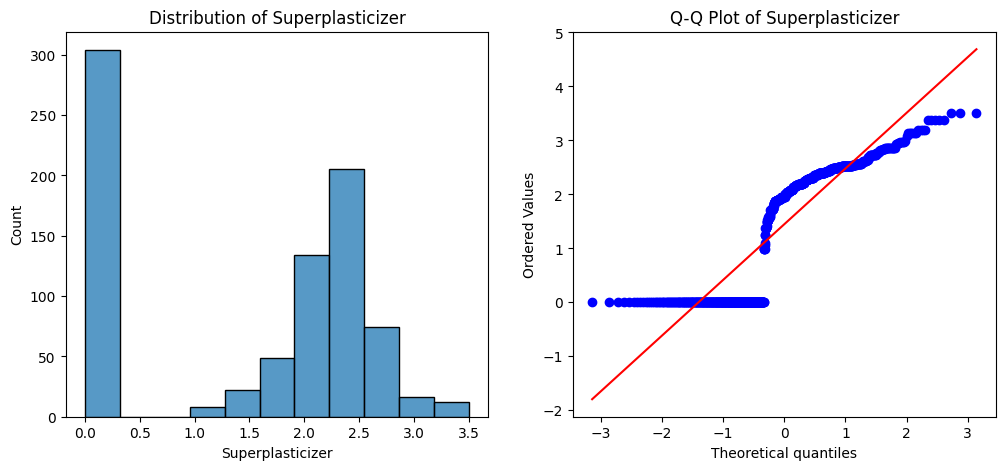

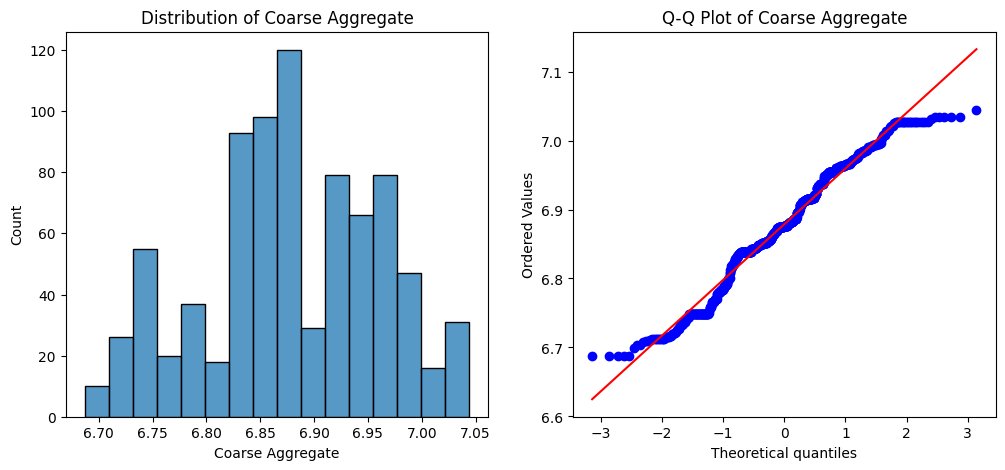

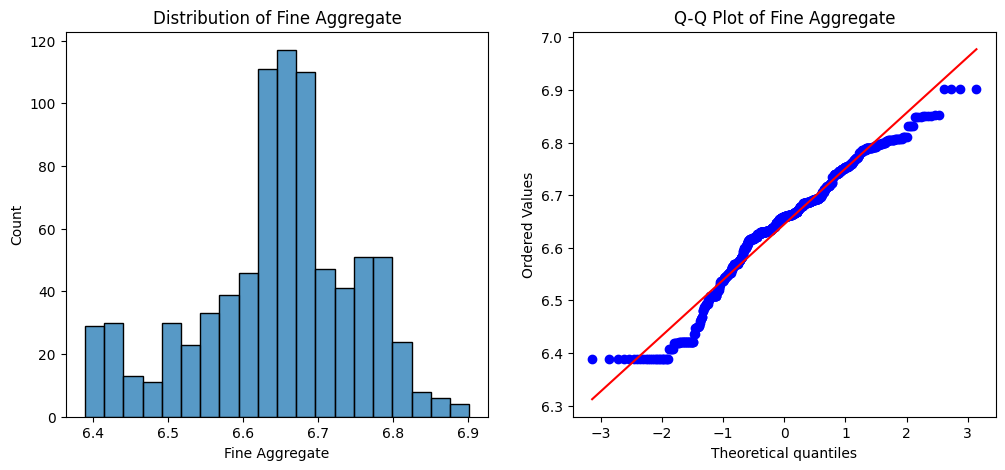

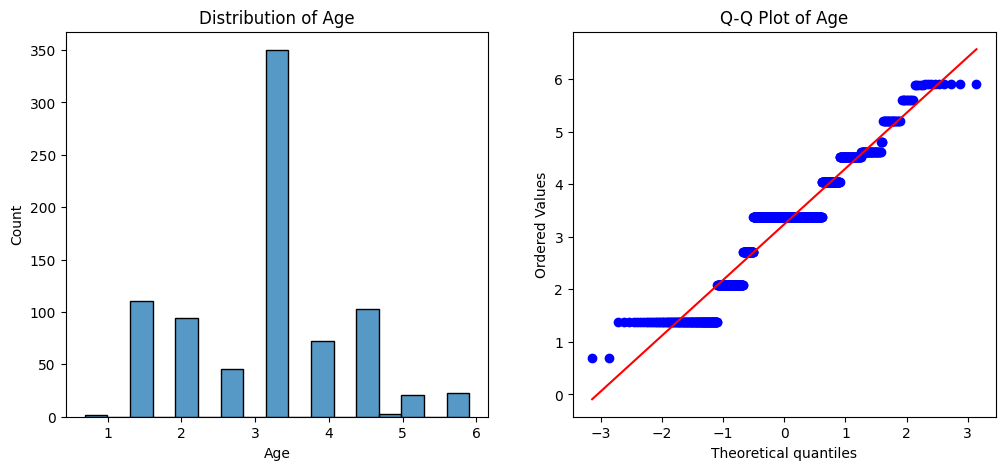

In [27]:
for col in X_train_transformed.columns:
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Distribution plot
    sns.histplot(X_train_transformed[col], ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")
    
    # Q-Q plot
    stats.probplot(X_train_transformed[col], dist="norm", plot=ax[1])
    ax[1].set_title(f"Q-Q Plot of {col}")
    
    plt.show()

In [29]:
# Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed_box = pt.fit_transform(x_train+0.000001)
X_test_transformed_box = pt.transform(x_test+0.000001)



In [31]:
lr = LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred2 = lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)

0.8108775091838559